<a href="https://colab.research.google.com/github/angelms2003/FernandezMartinezPolo-EML-RL/blob/main/Entornos_Complejos/juntar_graficas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook para juntae gráficas

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/14

In [1]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git

Cloning into 'FernandezMartinezPolo-EML-RL'...
remote: Enumerating objects: 484, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 484 (delta 67), reused 92 (delta 41), pack-reused 351 (from 1)
Receiving objects: 100% (484/484), 24.48 MiB | 13.83 MiB/s, done.
Resolving deltas: 100% (264/264), done.


In [2]:
!cd FernandezMartinezPolo-EML-RL/

In [4]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/FernandezMartinezPolo-EML-RL/Entornos_Complejos/src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/FernandezMartinezPolo-EML-RL/Entornos_Complejos/src', '/content/FernandezMartinezPolo-EML-RL/Entornos_Complejos/src']


# Unión de resultados para plots conjuntos (Entornos complejos y metodos tabulares)

Ahora vamos a generar algunas gráficas conjuntas de los cuatro algoritmos, para poder mostrar la comparación más fácilmente tanto en el informe escrito como en la presentación. Tomamos para la comparación la mejor opción de cada algoritmo, que fueron:

- Monte Carlo On Policy (epsilon= 0.6, decay= True)
- Monte Carlo Off Policy (epsilon= 0.3, decay= True)
- SARSA ()
- Q Learning ()

In [6]:
def draw_multiple_learning_curves(results_dict):
    """
    Representa varias curvas de entrenamiento en el mismo gráfico.

    results_dict:
        Diccionario donde:
        clave -> nombre experimento/agente
        valor -> lista con historial de métricas
    """

    first_key = next(iter(results_dict))
    x_axis = np.arange(len(results_dict[first_key]))

    fig, ax = plt.subplots(figsize=(10, 4))

    for experiment_name, history in results_dict.items():
        ax.plot(x_axis, history, label=experiment_name)

    ax.set_title("Comparativa de rendimiento")
    ax.set_xlabel("Número de episodio")
    ax.set_ylabel("Valor medio")
    ax.legend()

    ax.grid()
    plt.show()


def compute_running_mean(series, window):
    """
    Calcula un suavizado tipo media deslizante sobre una serie temporal.
    """
    kernel = np.full(window, 1.0 / window)
    return np.convolve(series, kernel, mode="valid")


def draw_episode_length_trend(length_history):
    """
    Visualiza la evolución del tamaño de los episodios junto con
    una versión suavizada para observar la tendencia global.
    """

    fig, ax = plt.subplots(figsize=(10, 4))

    # Señal original (transparente)
    ax.plot(length_history, alpha=0.25, color="forestgreen")

    # Tendencia suavizada
    smoothing_window = 100
    smoothed = compute_running_mean(length_history, smoothing_window)

    ax.plot(
        np.arange(len(smoothed)),
        smoothed,
        linewidth=2,
        color="darkgreen",
        label="Media suavizada"
    )

    ax.set_title("Evolución del tamaño de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()


def draw_episode_length_comparison(length_dict):
    """
    Compara la evolución de longitud de episodio entre varios experimentos.
    """

    palette = ["darkred", "navy", "darkgreen", "purple", "orange"]

    fig, ax = plt.subplots(figsize=(10, 4))

    smoothing_window = 100

    for idx, (label, values) in enumerate(length_dict.items()):

        color = palette[idx % len(palette)]

        # Señal original
        ax.plot(values, alpha=0.2, color=color)

        # Tendencia suavizada
        smoothed = compute_running_mean(values, smoothing_window)
        ax.plot(
            np.arange(len(smoothed)),
            smoothed,
            linewidth=2,
            color=color,
            label=label
        )

    ax.set_title("Comparativa de longitudes de episodio")
    ax.set_xlabel("Índice de episodio")
    ax.set_ylabel("Número de pasos")
    ax.legend()
    ax.grid()

    plt.show()

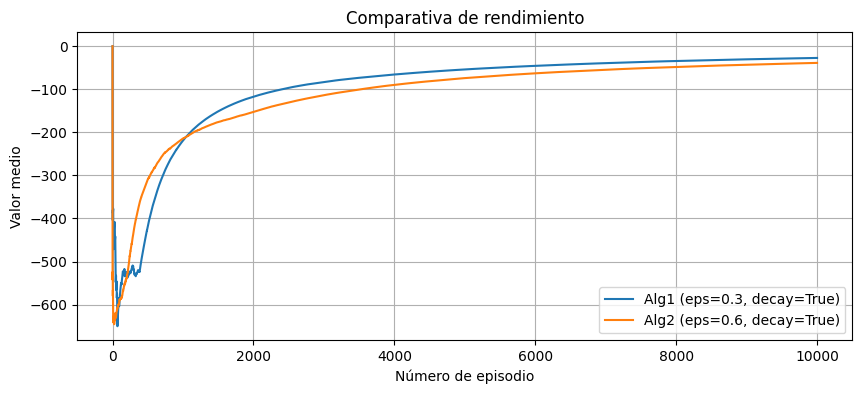

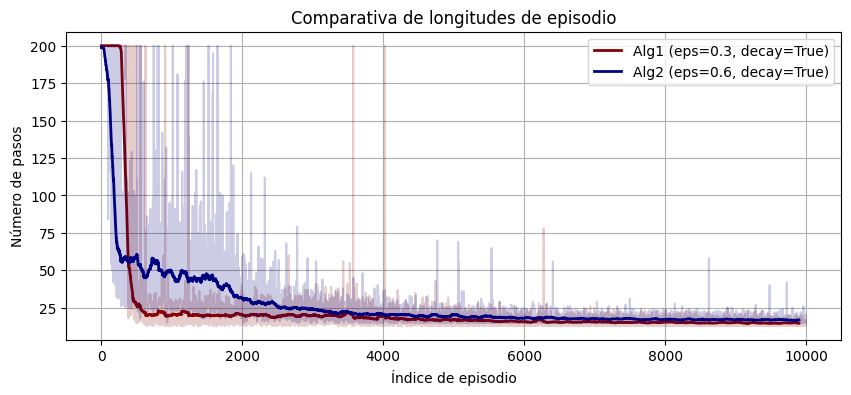

In [9]:
import numpy as np

# --- Cargar los datos ---
data_exp1 = np.load('/content/FernandezMartinezPolo-EML-RL/Entornos_Complejos/data/monte_carlo_off_results.npz', allow_pickle=True)
data_exp2 = np.load('/content/FernandezMartinezPolo-EML-RL/Entornos_Complejos/data/monte_carlo_results.npz', allow_pickle=True)

stats_exp1 = data_exp1["dict_stats"].item()
len_exp1 = data_exp1["dict_len"].item()

stats_exp2 = data_exp2["dict_stats"].item()
len_exp2 = data_exp2["dict_len"].item()

# --- Selección de algoritmos ---
keys_exp1 = list(stats_exp1.keys())
keys_exp2 = list(stats_exp2.keys())

alg1_key = keys_exp1[0]  # primer algoritmo del primer fichero
alg2_key = keys_exp2[4]  # quinto algoritmo del segundo fichero

alg_dict_stats = {
    f"Alg1 ({alg1_key})": stats_exp1[alg1_key],
    f"Alg2 ({alg2_key})": stats_exp2[alg2_key]
}

alg_dict_len = {
    f"Alg1 ({alg1_key})": len_exp1[alg1_key],
    f"Alg2 ({alg2_key})": len_exp2[alg2_key]
}

# --- Ploteo usando tus funciones ---
# Curvas de aprendizaje / stats
draw_multiple_learning_curves(alg_dict_stats)

# Longitud de episodios de cada algoritmo
draw_episode_length_comparison(alg_dict_len)
